# Breast Cancer Prediction Model

Dataset: https://www.kaggle.com/datasets/remyz5/curated-healthcare-and-genomics-datasets?utm_source=chatgpt.com


In [1]:
import pandas as pd
import numpy as np

In [2]:
import kagglehub

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print(path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
/kaggle/input/ibm-hr-analytics-attrition-dataset


In [3]:
import pandas as pd
import os

csv_path = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")

data = pd.read_csv(csv_path)

print(data.head())
print(data.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [4]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
data = data.drop([
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
], axis=1)

In [6]:
data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})

In [7]:
data = pd.get_dummies(data, drop_first=True)

data.head(3)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,True,False,False,False,False,False,False,False,True,True


In [8]:
X = data.drop("Attrition", axis=1)
y = data["Attrition"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8843537414965986


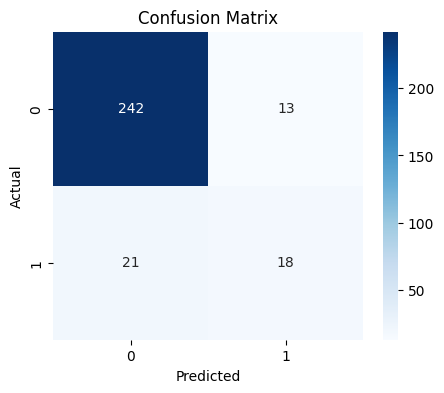

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_score(y_test, y_pred)

0.8843537414965986

In [19]:
precision_score(y_test, y_pred)

0.5806451612903226

In [20]:
recall_score(y_test, y_pred)

0.46153846153846156

In [21]:
f1_score(y_test, y_pred)

0.5142857142857142

In [22]:
y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.7916540975364506)

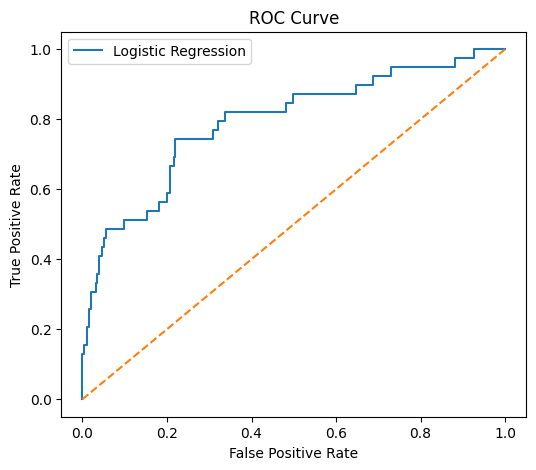

In [23]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.58      0.46      0.51        39

    accuracy                           0.88       294
   macro avg       0.75      0.71      0.72       294
weighted avg       0.88      0.88      0.88       294



In [ ]:
model.predict_proba(X_test[:5])

array([[0.93508199, 0.06491801],
       [0.9973644 , 0.0026356 ],
       [0.65738822, 0.34261178],
       [0.98714761, 0.01285239],
       [0.94932286, 0.05067714]])

In [25]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability (Class 1)": y_prob
})

results.head(10)

,Actual,Predicted,Probability (Class 1)
0,0,0,0.063220
1,0,0,0.002822
2,1,0,0.337819
3,0,0,0.013815
4,0,0,0.052543
5,0,0,0.334267
6,0,0,0.417114
7,0,0,0.036356
8,0,0,0.064675
9,0,0,0.014543


In [26]:
results.sample(10)

,Actual,Predicted,Probability (Class 1)
178,0,0,0.067028
56,0,0,0.430374
269,0,0,0.079956
140,0,1,0.697070
34,1,1,0.515348
96,0,0,0.019669
136,0,0,0.069934
235,0,0,0.005398
196,0,0,0.303533
189,0,0,0.007690
